# Fraud Model Training

Can we tell whether a payment is fraud, using only what we would actually know at
the moment it happens?

That last part is the hard bit. It is easy to build a model that looks brilliant
because it quietly peeked at the future. Most of the care in this notebook goes
into not doing that.

We pull features from Feast (the feature store), attach the real fraud labels,
train a model, and check how well it does.

The actual logic lives in `fraudstream_ml` and is covered by tests. This notebook
just calls it, so what runs here is the same code those tests check.

## 1. Setup

Nothing interesting here: imports, and loading the `.env` file so we can reach the
database and storage.

The one thing worth knowing is that this notebook has its own Python environment
with Feast, Spark and XGBoost pinned together, kept separate from the rest of the
project so their versions do not fight.

In [8]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT = Path.cwd().parent
REPO = PROJECT.parent
sys.path.insert(0, str(PROJECT / "src"))

for line in (REPO / ".env").read_text().splitlines():
    line = line.strip()
    if line and not line.startswith("#") and "=" in line:
        key, _, value = line.partition("=")
        os.environ.setdefault(key.strip(), value.strip())

FEAST_REPO = str(PROJECT.parent / "feature_store" / "feature_repo")
IMAGES = REPO / "images" / "ml"
IMAGES.mkdir(parents=True, exist_ok=True)
ARTIFACTS = PROJECT / "artifacts"

WINDOW_START, WINDOW_END = "2026-01-01", "2026-06-30"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})

print("feast repo:", FEAST_REPO)
print("window:", WINDOW_START, "->", WINDOW_END)

feast repo: /Users/Admin/MLOps/fraudstream/feature_store/feature_repo
window: 2026-01-01 -> 2026-06-30


In [9]:
from fraudstream_ml.dataset import (
    BATCH_FEATURE_REFS,
    coverage_report,
    entity_dataframe_sql,
    load_training_frame,
)
from fraudstream_ml.features import AVAILABILITY_FLAGS, prepare_features
from fraudstream_ml.split import chronological_split, split_summary
from fraudstream_ml.train import (
    TUNING_GRID,
    evaluate,
    load_bundle,
    save_bundle,
    scale_pos_weight,
    select_threshold,
    train_baseline,
    train_xgboost,
    tune_xgboost,
)

print(f"{len(BATCH_FEATURE_REFS)} batch feature refs requested from Feast")

23 batch feature refs requested from Feast


## 2. Get the data

We ask Feast one question: *for each of these payments, what did the customer and
the merchant look like at that exact moment?*

We hand it a SQL query rather than a table of rows. The data lives in Spark, so it
is far quicker to let the join happen there than to drag half a million rows into
this notebook and push them back out again.

Two deliberate choices in that query:

**The fraud label comes from its own separate table.** The payments table happens
to have an `is_fraud` column sitting right there, so joining to a second table
looks like pointless extra work. It is not. Keeping labels in their own place is
what stops them quietly leaking into somewhere they should not be.

**We ignore `transaction_status`.** It says whether the payment was approved,
declined or reversed, but that is decided *after* the fact. Train on it and every
score below would look wonderful and mean nothing.

In [4]:
print(entity_dataframe_sql(WINDOW_START, WINDOW_END))


        SELECT
            f.transaction_id,
            f.customer_id,
            f.merchant_dim_id AS merchant_id,
            f.event_time AS event_timestamp,
            CAST(f.amount AS DOUBLE) AS amount,
            f.channel,
            f.city,
            l.is_fraud
        FROM iceberg.gold.fact_transactions f
        JOIN iceberg.gold.transaction_labels l ON l.transaction_id = f.transaction_id
        WHERE f.event_time >= TIMESTAMP '2026-01-01 00:00:00'
          AND f.event_time < TIMESTAMP '2026-06-30 00:00:00'
    


In [6]:
started = time.time()
frame = load_training_frame(FEAST_REPO, WINDOW_START, WINDOW_END)
print(f"retrieved {len(frame):,} rows x {frame.shape[1]} columns in {time.time() - started:.0f}s")

/Users/Admin/MLOps/fraudstream/ml/.venv/lib/python3.12/site-packages/feast/infra/offline_stores/contrib/spark_offline_store/spark_source.py:99: RuntimeWarning: The spark data source API is an experimental feature in alpha development. This API is unstable and it could and most probably will be changed in the future.
  warnings.warn(
/Users/Admin/MLOps/fraudstream/ml/.venv/lib/python3.12/site-packages/feast/infra/offline_stores/contrib/spark_offline_store/spark.py:200: RuntimeWarning: The spark offline store is an experimental feature in alpha development. Some functionality may still be unstable so functionality can change in the future.
  warnings.warn(
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/13 13:46:34 WARN Utils: Your hostname, MacBook-Pro-3.local, resolves to a loopback address: 127.0.2.2; using 192.168.0.158 instead (on interface en0)
26/09/13 13:46:34 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading s

retrieved 500,000 rows x 31 columns in 55s


In [5]:
frame.head()

,transaction_id,customer_id,merchant_id,event_timestamp,amount,channel,city,is_fraud,txn_count_7d,txn_count_30d,amount_sum_7d,amount_sum_30d,amount_avg_7d,amount_avg_30d,distinct_merchant_count_7d,distinct_merchant_count_30d,declined_txn_count_7d,fraud_txn_count_30d,total_orders_90d,merchant_category,merchant_txn_count_1d,merchant_txn_count_7d,merchant_txn_count_30d,merchant_amount_sum_30d,merchant_amount_avg_30d,merchant_distinct_customer_count_1d,merchant_declined_txn_count_1d,merchant_fraud_rate_1d,merchant_prior_fraud_rate_30d,merchant_burst_ratio_1d_to_prior_30d,merchant_vs_category_amount_ratio_30d
0,txn_000000341420,cust_00005467,UNKNOWN,2026-01-01 07:18:08,98.84,online,New York,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,txn_000000483299,cust_00032303,UNKNOWN,2026-01-01 18:15:51,23.44,online,Los Angeles,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,txn_000000055690,cust_00071108,UNKNOWN,2026-01-01 19:38:54,21.81,card_present,New York,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,txn_000000062949,cust_00125912,UNKNOWN,2026-01-01 20:59:50,32.41,card_present,Atlanta,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,txn_000000171153,cust_00126046,UNKNOWN,2026-01-02 07:53:10,54.81,online,New York,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print(f"rows                 {len(frame):,}")
print(f"distinct transactions {frame['transaction_id'].nunique():,}")
print(f"date range           {frame['event_timestamp'].min()}  ->  {frame['event_timestamp'].max()}")
print(f"fraud rows           {int(frame['is_fraud'].sum()):,}")
print(f"fraud rate           {frame['is_fraud'].mean():.4%}")
print(f"null labels          {int(frame['is_fraud'].isna().sum())}")

rows                 500,000
distinct transactions 500,000
date range           2026-01-01 00:01:16  ->  2026-06-29 23:54:22
fraud rows           7,697
fraud rate           1.5394%
null labels          0


### How often does Feast actually have an answer?

When we ask what a customer looked like back then, Feast sometimes replies
**"I don't know"** and hands back blanks.

That is deliberate, not broken. Every feature has a shelf life. Customer stats go
stale after 31 days, so if someone has not shopped in months, their old numbers
are too out of date to trust and Feast refuses to serve them.

Most customers here shop rarely, a couple of times across six months, so for the
majority of payments we genuinely have no recent picture of them. Merchants are
the opposite: they are busy every single day, so their data is nearly always
fresh. That alone explains the numbers below.

This matters for one very practical reason: **it decides which model we can use.**
With this many blanks we need something that copes with missing values on its own.
XGBoost does. Most alternatives do not, and would force us either to throw those
rows away or to invent numbers to fill the gaps. Both are worse than admitting we
do not know.

In [7]:
coverage = coverage_report(frame)
for view, share in coverage.items():
    print(f"{view:32s} {share:7.2%}")

customer_rolling_features         29.87%
customer_orders_90d_features      54.34%
merchant_risk_features            82.28%


## 3. Prepare the features

Three things happen here, and one thing deliberately does not.

**We add a "do we know anything about this customer?" flag.** Instead of leaving
blanks as silent holes, we mark them. A customer we know nothing about really is
different from a quiet one, so that is information worth handing to the model
rather than hiding.

**We add details of the payment itself**: the amount, the hour of day, the channel,
the city. These are not history, they arrive with the payment, so using them is
entirely fair.

**We turn text into numbers.** Values like "grocery" or "online" become yes/no
columns, built from a fixed list so every run produces the same columns in the
same order.

**What we do not do is fill in the blanks.** They stay blank on purpose, and
XGBoost works out what to do with them.

In [8]:
prepared, feature_names = prepare_features(frame)

print(f"{len(feature_names)} model features\n")
groups = {
    "entity aggregates": [n for n in feature_names
                          if not n.startswith(("merchant_category_", "channel_", "city_"))
                          and n not in (*AVAILABILITY_FLAGS.values(), "amount", "event_hour")],
    "request-time numeric": ["amount", "event_hour"],
    "availability flags": list(AVAILABILITY_FLAGS.values()),
    "one-hot encoded": [n for n in feature_names
                        if n.startswith(("merchant_category_", "channel_", "city_"))],
}
for group, names in groups.items():
    print(f"{group} ({len(names)}):")
    print("   ", ", ".join(names), "\n")

51 model features

entity aggregates (22):
    txn_count_7d, txn_count_30d, amount_sum_7d, amount_sum_30d, amount_avg_7d, amount_avg_30d, distinct_merchant_count_7d, distinct_merchant_count_30d, declined_txn_count_7d, fraud_txn_count_30d, total_orders_90d, merchant_txn_count_1d, merchant_txn_count_7d, merchant_txn_count_30d, merchant_amount_sum_30d, merchant_amount_avg_30d, merchant_distinct_customer_count_1d, merchant_declined_txn_count_1d, merchant_fraud_rate_1d, merchant_prior_fraud_rate_30d, merchant_burst_ratio_1d_to_prior_30d, merchant_vs_category_amount_ratio_30d 

request-time numeric (2):
    amount, event_hour 

availability flags (3):
    customer_features_available, customer_orders_90d_available, merchant_features_available 

one-hot encoded (24):
    merchant_category_cash_transfer, merchant_category_electronics, merchant_category_fuel, merchant_category_grocery, merchant_category_healthcare, merchant_category_online_marketplace, merchant_category_restaurant, merchant_cate

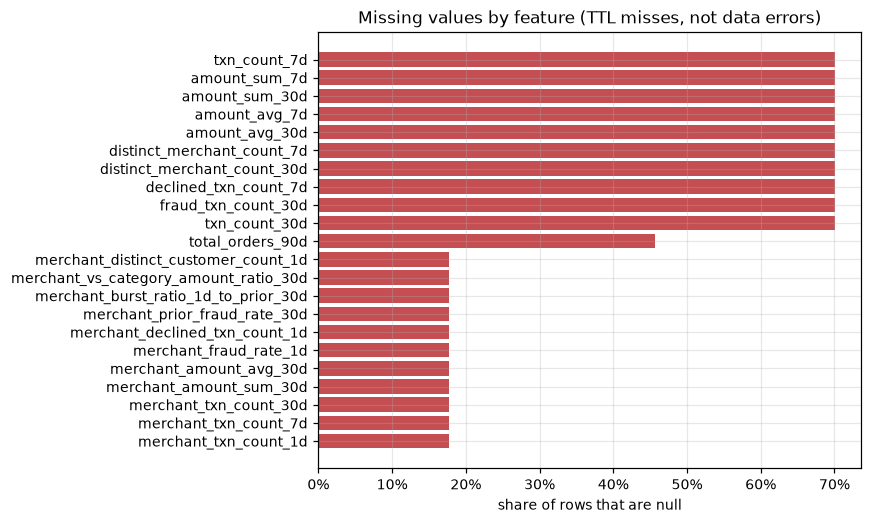

22 of 51 features carry nulls; 10 are more than half null


In [9]:
null_share = prepared[feature_names].isna().mean().sort_values(ascending=False)
null_share = null_share[null_share > 0]

fig, ax = plt.subplots(figsize=(8, max(2.5, 0.22 * len(null_share))))
ax.barh(null_share.index[::-1], null_share.values[::-1], color="#c44e52")
ax.set_xlabel("share of rows that are null")
ax.set_title("Missing values by feature (TTL misses, not data errors)")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
fig.tight_layout()
fig.savefig(IMAGES / "01-null-share-by-feature.png", bbox_inches="tight")
plt.show()

print(f"{len(null_share)} of {len(feature_names)} features carry nulls; "
      f"{(null_share > 0.5).sum()} are more than half null")

## 4. Split by time, not at random

We cut the data by date: train on the earliest months, validate on the next few
weeks, test on the final stretch. We deliberately do not shuffle.

Why that matters so much:

**Our features are summaries of the past.** "How much did this customer spend in
the last 30 days" on a June payment is partly built from their May payments.
Shuffle the rows and May could land in the test set while June sits in training,
so the model has effectively already seen the answer.

**The same goes for the labels.** Some features count *past frauds*. Shuffle, and a
fraud we are supposed to be predicting has already helped build a training row.

**The rows are not independent.** Half a million payments spread across roughly
40,000 merchants means the same merchant turns up on both sides, carrying its
history with it.

**And it asks the wrong question anyway.** In real life you train on the past and
predict the future. Shuffling asks the much easier question "can you fill a gap in
a period you have already seen?", which flatters the score.

Validation and test do different jobs. Validation is for tuning and picking the
cut-off. Test gets looked at exactly once, right at the end.

In [10]:
splits = chronological_split(prepared)
summary = split_summary(splits)
summary["share"] = summary["rows"] / summary["rows"].sum()
summary

,split,rows,start,end,fraud_rows,fraud_rate,share
0,train,348184,2026-01-01 00:01:16,2026-05-04 23:54:59,5306,0.015239,0.696368
1,validation,74782,2026-05-05 00:00:58,2026-05-29 23:59:11,1178,0.015752,0.149564
2,test,77034,2026-05-30 00:00:05,2026-06-29 23:54:22,1213,0.015746,0.154068


In [11]:
def xy(name):
    return splits[name][feature_names], splits[name]["is_fraud"]

X_train, y_train = xy("train")
X_val, y_val = xy("validation")
X_test, y_test = xy("test")

print(f"train      {len(X_train):>7,} rows   {int(y_train.sum()):>5,} fraud")
print(f"validation {len(X_val):>7,} rows   {int(y_val.sum()):>5,} fraud")
print(f"test       {len(X_test):>7,} rows   {int(y_test.sum()):>5,} fraud")
print(f"\nscale_pos_weight (negatives / positives on train) = {scale_pos_weight(y_train):.1f}")

train      348,184 rows   5,306 fraud
validation  74,782 rows   1,178 fraud
test        77,034 rows   1,213 fraud

scale_pos_weight (negatives / positives on train) = 64.6


## 5. Train

Three steps, in order:

1. **A simple model first**, as a yardstick. If the fancy one cannot beat plain
   logistic regression, it is not earning its keep. Note that this one needs the
   blanks filled in first, which is exactly the hassle XGBoost saves us.
2. **One XGBoost run**, which stops automatically once it stops improving.
3. **A small search** over a handful of settings, keeping whichever does best on
   validation.

Only about 1.5% of payments are fraud, so we tell the model to pay proportionally
more attention to them, and we judge progress on a measure built for rare events
rather than on plain accuracy.

In [12]:
started = time.time()
baseline = train_baseline(X_train, y_train)
baseline_val = evaluate(baseline, X_val, y_val)
print(f"baseline trained in {time.time() - started:.0f}s")
print(f"  validation PR-AUC  {baseline_val['pr_auc']:.4f}")
print(f"  validation ROC-AUC {baseline_val['roc_auc']:.4f}")

baseline trained in 5s
  validation PR-AUC  0.0284
  validation ROC-AUC 0.6657


In [13]:
started = time.time()
single = train_xgboost(X_train, y_train, X_val, y_val)
single_val = evaluate(single, X_val, y_val)
print(f"xgboost trained in {time.time() - started:.0f}s, stopped at iteration {single.best_iteration}")
print(f"  validation PR-AUC  {single_val['pr_auc']:.4f}")
print(f"  validation ROC-AUC {single_val['roc_auc']:.4f}")

xgboost trained in 2s, stopped at iteration 8
  validation PR-AUC  0.0269
  validation ROC-AUC 0.6513


In [14]:
started = time.time()
model, results = tune_xgboost(X_train, y_train, X_val, y_val, grid=TUNING_GRID)
print(f"{len(TUNING_GRID)} configs in {time.time() - started:.0f}s -- ranked by validation PR-AUC\n")
results

10 configs in 27s -- ranked by validation PR-AUC



,max_depth,learning_rate,min_child_weight,validation_pr_auc,validation_roc_auc,best_iteration
0,3,0.10,5,0.028800,0.662235,35
1,3,0.05,5,0.028729,0.664049,139
2,5,0.10,20,0.028439,0.663664,29
3,3,0.20,5,0.028297,0.663632,30
4,5,0.10,5,0.028127,0.664418,34
5,5,0.05,5,0.028044,0.659913,31
6,7,0.05,10,0.027733,0.659215,21
7,7,0.20,10,0.027170,0.653768,8
8,5,0.20,5,0.027134,0.653932,28
9,7,0.10,10,0.027104,0.653692,26


In [15]:
best = results.iloc[0]
print("selected config:")
for key in ("max_depth", "learning_rate", "min_child_weight"):
    print(f"  {key:18s} {best[key]}")
print(f"  best_iteration     {int(best['best_iteration'])}")
print(f"\nvalidation PR-AUC   baseline {baseline_val['pr_auc']:.4f}"
      f"  ->  tuned xgboost {best['validation_pr_auc']:.4f}")

selected config:
  max_depth          3.0
  learning_rate      0.1
  min_child_weight   5.0
  best_iteration     35

validation PR-AUC   baseline 0.0284  ->  tuned xgboost 0.0288


## 6. Evaluate

We choose the decision cut-off using validation, then score the test set **once**.
Test never gets a vote in any decision. That is the only reason its number means
anything.

In [16]:
threshold = select_threshold(y_val, model.predict_proba(X_val)[:, 1])
print(f"threshold chosen on validation: {threshold:.4f}")
print("(0.5 is the wrong default here -- at a ~1.5% base rate a calibrated model")
print(" rarely pushes a score past it, so the default predicts almost nothing)")

threshold chosen on validation: 0.6282
(0.5 is the wrong default here -- at a ~1.5% base rate a calibrated model
 rarely pushes a score past it, so the default predicts almost nothing)


In [17]:
test_metrics = evaluate(model, X_test, y_test, threshold=threshold)

for key in ("pr_auc", "roc_auc", "precision", "recall", "f1", "accuracy"):
    print(f"{key:12s} {test_metrics[key]:.4f}")
print(f"\npositives in test      {test_metrics['positives']:,}")
print(f"flagged by the model   {test_metrics['predicted_positives']:,}")

pr_auc       0.0279
roc_auc      0.6579
precision    0.0333
recall       0.1443
f1           0.0541
accuracy     0.9206

positives in test      1,213
flagged by the model   5,253


### Why accuracy comes last here, never first

Only about 1.5% of these payments are fraud. So a model that simply says "not
fraud" to everything is right roughly 98.4% of the time, while catching precisely
zero fraud.

That is the trap. Accuracy rewards guessing the common answer, so a useless model
can easily outscore a genuinely useful one.

PR-AUC is the number to watch instead, because it only cares about how well we
find the rare thing. The fair comparison for it is the fraud rate itself, which is
roughly what pure guesswork would score.

In [18]:
base_rate = y_test.mean()
print(f"all-negative predictor accuracy   {1 - base_rate:.4%}")
print(f"this model's accuracy             {test_metrics['accuracy']:.4%}")
print()
print(f"random-classifier PR-AUC (= base rate)  {base_rate:.4f}")
print(f"this model's PR-AUC                     {test_metrics['pr_auc']:.4f}"
      f"   ({test_metrics['pr_auc'] / base_rate:.2f}x base rate)")

all-negative predictor accuracy   98.4254%
this model's accuracy             92.0606%

random-classifier PR-AUC (= base rate)  0.0157
this model's PR-AUC                     0.0279   (1.77x base rate)


In [19]:
from sklearn.metrics import confusion_matrix

scores_test = model.predict_proba(X_test)[:, 1]
matrix = confusion_matrix(y_test, (scores_test >= threshold).astype(int))
pd.DataFrame(
    matrix,
    index=pd.Index(["actual legit", "actual fraud"], name=""),
    columns=pd.Index(["predicted legit", "predicted fraud"], name=f"threshold={threshold:.4f}"),
)

threshold=0.6282,predicted legit,predicted fraud
,,
actual legit,70743,5078
actual fraud,1038,175


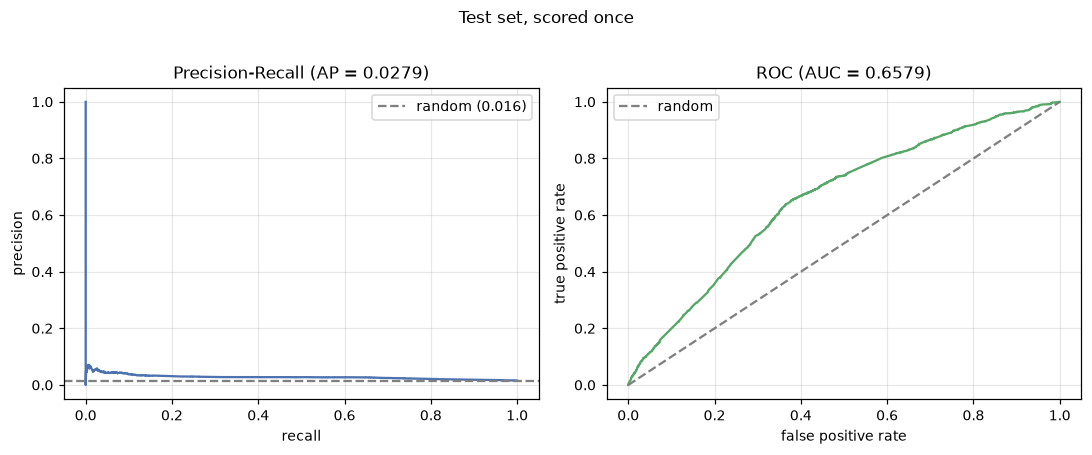

In [20]:
from sklearn.metrics import precision_recall_curve, roc_curve

precision, recall, _ = precision_recall_curve(y_test, scores_test)
false_positive, true_positive, _ = roc_curve(y_test, scores_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(recall, precision, color="#4c72b0")
axes[0].axhline(base_rate, ls="--", c="grey", label=f"random ({base_rate:.3f})")
axes[0].set(xlabel="recall", ylabel="precision",
            title=f"Precision-Recall (AP = {test_metrics['pr_auc']:.4f})")
axes[0].legend()
axes[1].plot(false_positive, true_positive, color="#55a868")
axes[1].plot([0, 1], [0, 1], ls="--", c="grey", label="random")
axes[1].set(xlabel="false positive rate", ylabel="true positive rate",
            title=f"ROC (AUC = {test_metrics['roc_auc']:.4f})")
axes[1].legend()
fig.suptitle("Test set, scored once", y=1.02)
fig.tight_layout()
fig.savefig(IMAGES / "02-test-pr-and-roc-curves.png", bbox_inches="tight")
plt.show()

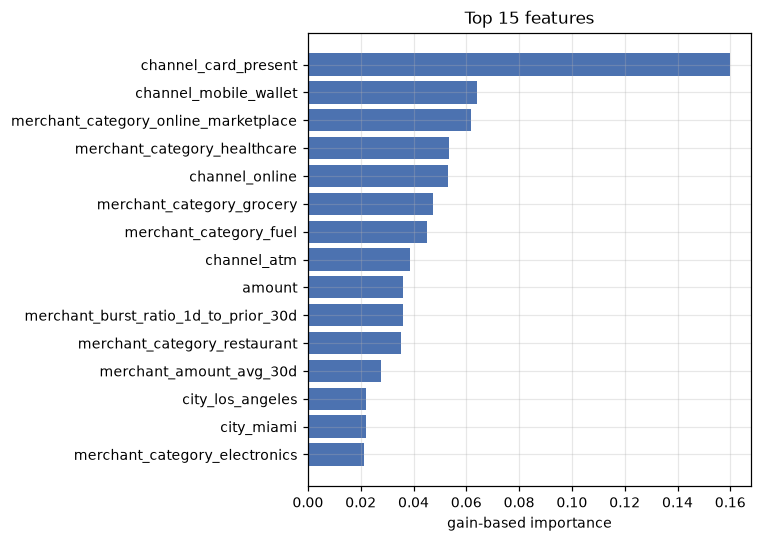

channel_card_present                    0.159956
channel_mobile_wallet                   0.064224
merchant_category_online_marketplace    0.061742
merchant_category_healthcare            0.053510
channel_online                          0.053176
merchant_category_grocery               0.047524
merchant_category_fuel                  0.044933
channel_atm                             0.038625
amount                                  0.036186
merchant_burst_ratio_1d_to_prior_30d    0.035957
merchant_category_restaurant            0.035223
merchant_amount_avg_30d                 0.027631
city_los_angeles                        0.022062
city_miami                              0.022039
merchant_category_electronics           0.021185


In [21]:
importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
top = importance.head(15)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top.index[::-1], top.values[::-1], color="#4c72b0")
ax.set_xlabel("gain-based importance")
ax.set_title("Top 15 features")
fig.tight_layout()
fig.savefig(IMAGES / "03-feature-importance.png", bbox_inches="tight")
plt.show()

print(top.to_string())

### Being honest about this result

The model beats the simple baseline and does clearly better than guessing, but it
is not a strong fraud detector. That is worth explaining rather than dressing up.

The reason sits in the data, not in the pipeline. Fraud here was created using a
few hidden traits, most importantly whether a payment belonged to a coordinated
fraud ring, along with how risky a particular customer or merchant was considered.
None of those were ever written into the data we can read. They shaped the answer
but were never saved.

Everything we *can* see is already in the model. What is left simply is not in the
data, so there is a hard ceiling here. The only way through it would be to go back
and record those hidden traits, which would make the score look better without
making the model any smarter.

## 7. Save the model

We save more than the model itself. The file also carries the exact list of columns
in the exact order, plus the decision cut-off we settled on.

Without those, anything loading this model later has to guess. A column order that
is silently different is the kind of bug that produces confident, completely wrong
answers.

In [22]:
bundle_path = save_bundle(
    ARTIFACTS / "fraud_detection_model.joblib",
    model=model,
    feature_names=feature_names,
    threshold=threshold,
    metrics=test_metrics,
)
print(f"saved {bundle_path.stat().st_size / 1024:.0f} KB -> {bundle_path.relative_to(REPO)}")

saved 112 KB -> ml/artifacts/fraud_model.joblib


In [23]:
reloaded = load_bundle(bundle_path)

print("bundle contents:")
for key, value in reloaded.items():
    shown = f"{len(value)} columns" if key == "feature_names" else (
        f"{len(value)} metrics" if key == "metrics" else value)
    print(f"  {key:14s} {type(value).__name__:12s} {shown if key != 'model' else ''}")

one_row = X_test.iloc[[0]][reloaded["feature_names"]]
from_disk = float(reloaded["model"].predict_proba(one_row)[:, 1][0])
in_memory = float(model.predict_proba(one_row)[:, 1][0])

print(f"\nre-scoring one row through the reloaded artifact:")
print(f"  in memory  {in_memory:.10f}")
print(f"  from disk  {from_disk:.10f}")
print(f"  identical  {from_disk == in_memory}")
print(f"  decision   {'FRAUD' if from_disk >= reloaded['threshold'] else 'legit'}"
      f" at threshold {reloaded['threshold']:.4f}")

bundle contents:
  model          XGBClassifier 
  feature_names  list         51 columns
  threshold      float        0.6281833052635193
  metrics        dict         9 metrics
  trained_at     str          2026-09-13T17:25:50.274428+00:00

re-scoring one row through the reloaded artifact:
  in memory  0.5472912788
  from disk  0.5472912788
  identical  True
  decision   legit at threshold 0.6282


## Summary

| |                                              |
|---|----------------------------------------------|
| Payments used | 500,000, about 1.5% fraud                    |
| Features | 51                                           |
| Split | by date: 70% train, 15% validation, 15% test |
| Model | XGBoost, settings chosen on validation       |
| Test set | scored once, at the very end                 |
| Saved to | `ml/artifacts/fraud_detection_model.joblib`  |

The short version: we used only what we would have known at the time, kept the
labels in their own table, split by date so nothing leaks backwards, chose the
cut-off on validation instead of assuming 0.5, and saved everything needed to
reproduce a score later.